### 0. Importing modules and data

In [1]:
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
from pickle import dump

In [2]:
Xtrain = pd.read_csv('../data/processed/SplitData/NormData/Clean_Xtrain_norm.csv')
Xtest = pd.read_csv('../data/processed/SplitData/NormData/Clean_Xtest_norm.csv')
ytrain = pd.read_csv('../data/processed/SplitData/Clean_ytrain.csv')
ytest = pd.read_csv('../data/processed/SplitData/Clean_ytest.csv')

### 1. Random Forest
#### 1.1 Init and train

In [3]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(Xtrain, ytrain)

/home/vscode/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

#### 1.2 Prediction and test

In [4]:
ypred = random_forest.predict(Xtest)
accuracy = accuracy_score(ytest, ypred)
print("Accuracy:", accuracy)

Accuracy: 0.7359307359307359


The random forest has improved accuracy compared to the optimized decision tree.

### 2. Analyzing the impact of the hyperparameters

In [5]:
n_estimators_values = [50, 100, 200,300,500,800]
bootstrap_values = [True, False]

accuracy_matrix = np.zeros((len(n_estimators_values), len(bootstrap_values)))

for i, n_estimators in enumerate(n_estimators_values):
    for j, bootstrap in enumerate(bootstrap_values):
        random_forest = RandomForestClassifier(n_estimators=n_estimators, bootstrap=bootstrap, random_state=42)        
        random_forest.fit(Xtrain, ytrain)
        
        ypred = random_forest.predict(Xtest)    
        accuracy = accuracy_score(ytest, ypred)
        
        accuracy_matrix[i, j] = accuracy


/home/vscode/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape o

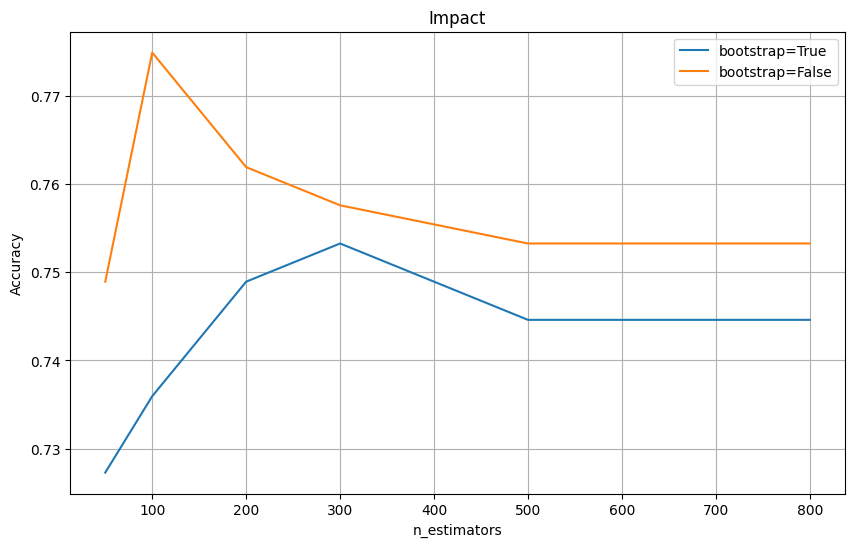

In [6]:
plt.figure(figsize=(10, 6))
for j, bootstrap in enumerate(bootstrap_values):
    plt.plot(n_estimators_values, accuracy_matrix[:, j], label=f"bootstrap={bootstrap}")

plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Impact')
plt.legend()
plt.grid(True)

Setting Bootstrap to False always results in better accuracy. If we fix this option, the accuracy increases up to 100 trees but then decays exponentially, stabilizing from 500 trees onwards. If we set Bootstrap to True, the best accuracy is achieved with 300 trees and then begins to decay due to model overfitting, stabilizing from 500 trees onwards.

Si incluimos ahora max_features en esta comparativa:

In [7]:
max_features_values = ['sqrt', 'log2', None]

accuracy_matrix = np.zeros((len(n_estimators_values), len(bootstrap_values), len(max_features_values)))

for i, n_estimators in enumerate(n_estimators_values):
    for j, bootstrap in enumerate(bootstrap_values):
        for k, max_features in enumerate(max_features_values):
            random_forest = RandomForestClassifier(n_estimators=n_estimators, bootstrap=bootstrap, max_features=max_features, random_state=42)
            random_forest.fit(Xtrain, ytrain)
            
            ypred = random_forest.predict(Xtest)
            accuracy = accuracy_score(ytest, ypred)
            
            accuracy_matrix[i, j, k] = accuracy

/home/vscode/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape o

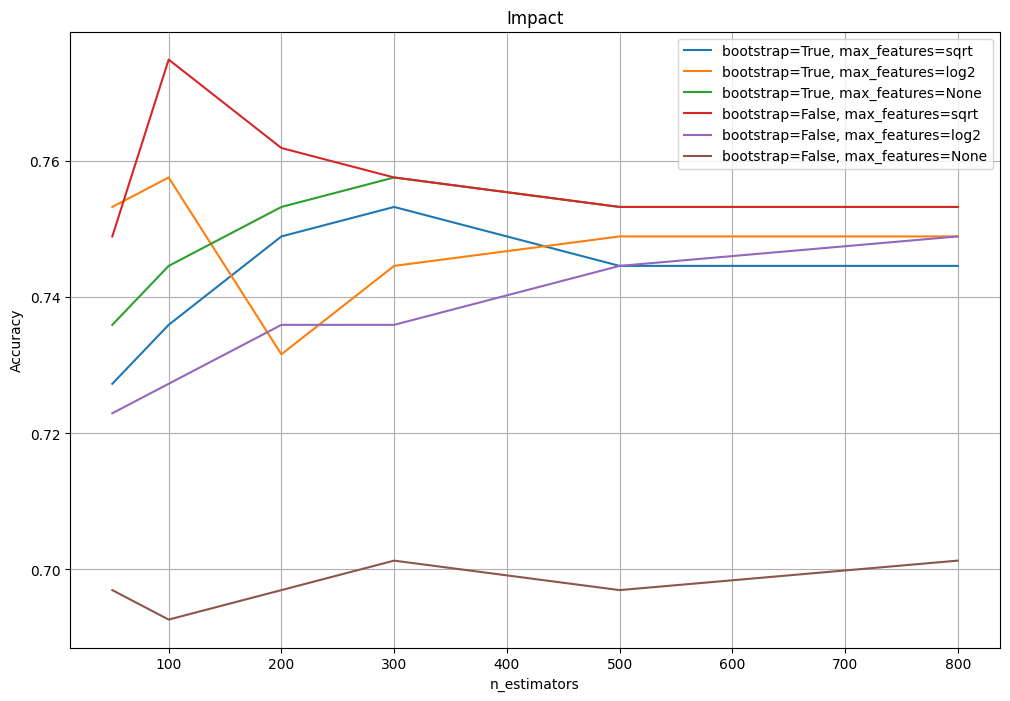

In [8]:
plt.figure(figsize=(12, 8))
for j, bootstrap in enumerate(bootstrap_values):
    for k, max_features in enumerate(max_features_values):
        plt.plot(n_estimators_values, accuracy_matrix[:, j, k], label=f"bootstrap={bootstrap}, max_features={max_features}")

plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Impact')
plt.legend()
plt.grid(True)

We see that the best combination is n_estimators = 100, bootstrap=False, and max_features=sqrt, which coincides with the best option from the previous comparison since sqrt is the default value of max_features.

In [11]:
optimal_model = RandomForestClassifier(n_estimators=100, bootstrap=False, max_features='sqrt', random_state=42)
optimal_model.fit(Xtrain, ytrain)
dump(optimal_model, open("../data/processed/Models/RForest-n_100-bootstrap_F-maxf_sqrt.sav", "wb"))

/home/vscode/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
